# **Problem Statement:**

Can we classify whether a country is experiencing a high tuberculosis (TB) burden  and what are the key factors?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from statistics import mean
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sb.set()
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()
data = pd.read_csv('TB_Burden_Country.csv', encoding='ISO-8859-1')

TypeError: 'NoneType' object is not subscriptable

In [ ]:
data.shape

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5120 entries, 0 to 5119
Data columns (total 47 columns):
 #   Column                                                                                          Non-Null Count  Dtype  
---  ------                                                                                          --------------  -----  
 0   Country or territory name                                                                       5120 non-null   object 
 1   ISO 2-character country/territory code                                                          5096 non-null   object 
 2   ISO 3-character country/territory code                                                          5120 non-null   object 
 3   ISO numeric country/territory code                                                              5120 non-null   int64  
 4   Region                                                                                          5120 non-null   object 
 5   Year         

In [ ]:
data.describe()

,ISO numeric country/territory code,Year,Estimated total population number,Estimated prevalence of TB (all forms) per 100 000 population,"Estimated prevalence of TB (all forms) per 100 000 population, low bound","Estimated prevalence of TB (all forms) per 100 000 population, high bound",Estimated prevalence of TB (all forms),"Estimated prevalence of TB (all forms), low bound","Estimated prevalence of TB (all forms), high bound","Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population","Estimated mortality of TB cases (all forms, excluding HIV), per 100 000 population, low bound","Estimated mortality of TB cases (all forms, excluding HIV), per 100 000 population, high bound","Estimated number of deaths from TB (all forms, excluding HIV)","Estimated number of deaths from TB (all forms, excluding HIV), low bound","Estimated number of deaths from TB (all forms, excluding HIV), high bound","Estimated mortality of TB cases who are HIV-positive, per 100 000 population","Estimated mortality of TB cases who are HIV-positive, per 100 000 population, low bound","Estimated mortality of TB cases who are HIV-positive, per 100 000 population, high bound",Estimated number of deaths from TB in people who are HIV-positive,"Estimated number of deaths from TB in people who are HIV-positive, low bound","Estimated number of deaths from TB in people who are HIV-positive, high bound",Estimated incidence (all forms) per 100 000 population,"Estimated incidence (all forms) per 100 000 population, low bound","Estimated incidence (all forms) per 100 000 population, high bound",Estimated number of incident cases (all forms),"Estimated number of incident cases (all forms), low bound","Estimated number of incident cases (all forms), high bound",Estimated HIV in incident TB (percent),"Estimated HIV in incident TB (percent), low bound","Estimated HIV in incident TB (percent), high bound",Estimated incidence of TB cases who are HIV-positive per 100 000 population,"Estimated incidence of TB cases who are HIV-positive per 100 000 population, low bound","Estimated incidence of TB cases who are HIV-positive per 100 000 population, high bound",Estimated incidence of TB cases who are HIV-positive,"Estimated incidence of TB cases who are HIV-positive, low bound","Estimated incidence of TB cases who are HIV-positive, high bound",Method to derive TBHIV estimates,"Case detection rate (all forms), percent","Case detection rate (all forms), percent, low bound","Case detection rate (all forms), percent, high bound"
count,5120.000000,5120.000000,5.120000e+03,5120.000000,5100.000000,5100.000000,5.120000e+03,5.100000e+03,5.100000e+03,5120.000000,5120.000000,5120.000000,5120.000000,5120.000000,5120.000000,5120.000000,3178.000000,3178.000000,5120.000000,3178.000000,3178.000000,5120.000000,5026.000000,5026.000000,5.120000e+03,5.026000e+03,5.026000e+03,3645.000000,3642.000000,3642.000000,3645.000000,3642.000000,3642.000000,3645.000000,3642.000000,3642.000000,0.0,4671.000000,4671.000000,4671.000000
mean,433.576563,2001.549023,2.915671e+07,194.386100,101.815353,321.006367,6.654332e+04,4.615915e+04,9.319791e+04,20.174426,13.379484,27.393916,6863.985914,4716.536096,9101.159256,11.829012,14.224248,24.824956,1798.730236,2157.701344,3812.193046,134.694076,121.647815,154.444174,4.218835e+04,3.901973e+04,4.725424e+04,11.179119,9.150986,13.379267,40.228274,33.892320,47.326378,6095.426979,5215.147573,7363.644445,NaN,68.217851,61.959409,75.854492
std,255.116018,6.933272,1.183725e+08,259.016385,145.259349,421.326139,3.249488e+05,2.711918e+05,3.938631e+05,32.893800,22.322593,44.594122,30554.560700,20718.668326,41925.477850,45.436586,41.988779,74.167187,7915.691847,7404.182344,12902.026168,190.032361,170.077250,214.817762,1.865701e+05,1.762540e+05,2.015837e+05,17.133550,14.330585,20.079531,125.175567,105.557348,147.004849,22807.804792,19993.703601,26548.834113,NaN,25.465391,23.603155,29.277633
min,4.000000,1990.000000,1.129000e+03,0.000000,0.110000,0.770000,0.000000e+00

# **Data Preparation/Cleaning**

In [ ]:
# Step 1: Load your CSV dataset into a DataFrame
df_tb_cleaned = pd.read_csv("TB_Burden_Country.csv")  # make sure the CSV is in the same folder

# Show the first few rows
df_tb_cleaned.head()


,Country or territory name,ISO 2-character country/territory code,ISO 3-character country/territory code,ISO numeric country/territory code,Region,Year,Estimated total population number,Estimated prevalence of TB (all forms) per 100 000 population,"Estimated prevalence of TB (all forms) per 100 000 population, low bound","Estimated prevalence of TB (all forms) per 100 000 population, high bound",Estimated prevalence of TB (all forms),"Estimated prevalence of TB (all forms), low bound","Estimated prevalence of TB (all forms), high bound",Method to derive prevalence estimates,"Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population","Estimated mortality of TB cases (all forms, excluding HIV), per 100 000 population, low bound","Estimated mortality of TB cases (all forms, excluding HIV), per 100 000 population, high bound","Estimated number of deaths from TB (all forms, excluding HIV)","Estimated number of deaths from TB (all forms, excluding HIV), low bound","Estimated number of deaths from TB (all forms, excluding HIV), high bound","Estimated mortality of TB cases who are HIV-positive, per 100 000 population","Estimated mortality of TB cases who are HIV-positive, per 100 000 population, low bound","Estimated mortality of TB cases who are HIV-positive, per 100 000 population, high bound",Estimated number of deaths from TB in people who are HIV-positive,"Estimated number of deaths from TB in people who are HIV-positive, low bound","Estimated number of deaths from TB in people who are HIV-positive, high bound",Method to derive mortality estimates,Estimated incidence (all forms) per 100 000 population,"Estimated incidence (all forms) per 100 000 population, low bound","Estimated incidence (all forms) per 100 000 population, high bound",Estimated number of incident cases (all forms),"Estimated number of incident cases (all forms), low bound","Estimated number of incident cases (all forms), high bound",Method to derive incidence estimates,Estimated HIV in incident TB (percent),"Estimated HIV in incident TB (percent), low bound","Estimated HIV in incident TB (percent), high bound",Estimated incidence of TB cases who are HIV-positive per 100 000 population,"Estimated incidence of TB cases who are HIV-positive per 100 000 population, low bound","Estimated incidence of TB cases who are HIV-positive per 100 000 population, high bound",Estimated incidence of TB cases who are HIV-positive,"Estimated incidence of TB cases who are HIV-positive, low bound","Estimated incidence of TB cases who are HIV-positive, high bound",Method to derive TBHIV estimates,"Case detection rate (all forms), percent","Case detection rate (all forms), percent, low bound","Case detection rate (all forms), percent, high bound"
0,Afghanistan,AF,AFG,4,EMR,1990,11731193,306.0,156.0,506.0,36000.0,18000.0,59000.0,predicted,37.0,24.0,54.0,4300.0,2800.0,6400.0,0.04,0.03,0.05,5.0,4.1,6.0,Indirect,189.0,157.0,238.0,22000.0,18000.0,28000.0,NaN,0.06,0.04,0.08,0.11,0.08,0.14,12.0,9.4,16.0,NaN,20.0,15.0,24.0
1,Afghanistan,AF,AFG,4,EMR,1991,12612043,343.0,178.0,562.0,43000.0,22000.0,71000.0,predicted,46.0,29.0,61.0,5800.0,3700.0,7700.0,0.06,0.05,0.08,8.0,6.2,10.0,Indirect,191.0,167.0,227.0,24000.0,21000.0,29000.0,NaN,0.07,0.06,0.09,0.13,0.11,0.16,17.0,14.0,20.0,NaN,96.0,80.0,110.0
2,Afghanistan,AF,AFG,4,EMR,1992,13811876,371.0,189.0,614.0,51000.0,26000.0,85000.0,predicted,54.0,34.0,68.0,7400.0,4700.0,9400.0,0.08,0.06,0.10,11.0,8.3,14.0,Indirect,191.0,171.0,217.0,26000.0,24000.0,30000.0,NaN,0.08,0.07,0.10,0.16,0.14,0.18,22.0,19.0,24.0,NaN,NaN,NaN,NaN
3,Afghanistan,AF,AFG,4,EMR,1993,15175325,392.0,194.0,657.0,59000.0,30000.0,100000.0,predicted,60.0,38.0,73.0,9100.0,5800.0,11000.0,0.11,0.09,0.14,17.0,13.0,21.0,Indirect,189.0,171.0,209.0,29000.0,26000.0,32000.0,NaN,0.10,0.09,0.11,0.19,0.17,0.21,28.0,25.0,31.0,NaN,NaN,NaN,NaN
4,Afghanistan,AF,AFG,4,EMR,1994,16485018,410.0,198.0,697.0,68000.0,33000.0,110000.0,predicted,65.0,41.0,79.0,11000.0,6800.0,13000.0,0.13

Shortlisting the 8 Columns necessary for Key Factors

In [ ]:
df_tb_cleaned = data[[
    "Country or territory name",
    "Year",
    "Estimated prevalence of TB (all forms) per 100 000 population",
    "Estimated incidence (all forms) per 100 000 population",
    "Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population",
    "Estimated mortality of TB cases who are HIV-positive, per 100 000 population",
    "Estimated HIV in incident TB (percent)",
    "Case detection rate (all forms), percent"
]].copy()

In [ ]:
print(df_tb_cleaned.columns.tolist())

['Country or territory name', 'Year', 'Estimated prevalence of TB (all forms) per 100 000 population', 'Estimated incidence (all forms) per 100 000 population', 'Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population', 'Estimated mortality of TB cases who are HIV-positive, per 100 000 population', 'Estimated HIV in incident TB (percent)', 'Case detection rate (all forms), percent']


# **Interpolating**

In [ ]:
# Sort first for meaningful interpolation across years within each country
df_tb_cleaned = df_tb_cleaned.sort_values(by=["Country or territory name", "Year"])

# Apply interpolation to selected numeric columns, grouped by country
numeric_columns_to_interpolate = [
    "Estimated prevalence of TB (all forms) per 100 000 population",
    "Estimated incidence (all forms) per 100 000 population",
    "Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population",
    "Estimated mortality of TB cases who are HIV-positive, per 100 000 population",
    "Estimated HIV in incident TB (percent)",
    "Case detection rate (all forms), percent"
]

for col in numeric_columns_to_interpolate:
    df_tb_cleaned[col] = df_tb_cleaned.groupby("Country or territory name")[col].transform(lambda x: x.interpolate())


# **Classifying Countries with High TB Burden**

We added a new column that classifies if a country is experiencing High TB Burden. The benchmark numbers are referenced from WHO.

In [ ]:
df_tb_cleaned["High_TB_Burden"] = (
    (df_tb_cleaned["Estimated incidence (all forms) per 100 000 population"] > 100) |
    (df_tb_cleaned["Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population"] > 10) |
    (df_tb_cleaned["Estimated prevalence of TB (all forms) per 100 000 population"] > 100) |
    (df_tb_cleaned["Case detection rate (all forms), percent"] < 60)
)


# **Dropping countries with missing data (Case detection rate)**

In [ ]:
df_tb_cleaned["Case detection rate (all forms), percent"].replace('', np.nan, inplace=True)

df_tb_cleaned

,Country or territory name,Year,Estimated prevalence of TB (all forms) per 100 000 population,Estimated incidence (all forms) per 100 000 population,"Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population","Estimated mortality of TB cases who are HIV-positive, per 100 000 population",Estimated HIV in incident TB (percent),"Case detection rate (all forms), percent",High_TB_Burden
0,Afghanistan,1990,306.0,189.0,37.0,0.04,0.06,20.0,True
1,Afghanistan,1991,343.0,191.0,46.0,0.06,0.07,96.0,True
2,Afghanistan,1992,371.0,191.0,54.0,0.08,0.08,80.6,True
3,Afghanistan,1993,392.0,189.0,60.0,0.11,0.10,65.2,True
4,Afghanistan,1994,410.0,188.0,65.0,0.13,0.11,49.8,True
...,...,...,...,...,...,...,...,...,...
5115,Zimbabwe,2009,449.0,673.0,39.0,206.00,76.00,50.0,True
5116,Zimbabwe,2010,415.0,635.0,36.0,196.00,77.00,53.0,True
5117,Zimbabwe,2011,417.0,602.0,38.0,176.00,75.00,48.0,True
5118,Zimbabwe,2012,425.0,575.0,41.0,160.00,72.00,45.0,True


In [ ]:
df_tb_cleaned.dropna(subset=["Case detection rate (all forms), percent"], inplace=True)

df_tb_cleaned

,Country or territory name,Year,Estimated prevalence of TB (all forms) per 100 000 population,Estimated incidence (all forms) per 100 000 population,"Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population","Estimated mortality of TB cases who are HIV-positive, per 100 000 population",Estimated HIV in incident TB (percent),"Case detection rate (all forms), percent",High_TB_Burden
0,Afghanistan,1990,306.0,189.0,37.0,0.04,0.06,20.0,True
1,Afghanistan,1991,343.0,191.0,46.0,0.06,0.07,96.0,True
2,Afghanistan,1992,371.0,191.0,54.0,0.08,0.08,80.6,True
3,Afghanistan,1993,392.0,189.0,60.0,0.11,0.10,65.2,True
4,Afghanistan,1994,410.0,188.0,65.0,0.13,0.11,49.8,True
...,...,...,...,...,...,...,...,...,...
5115,Zimbabwe,2009,449.0,673.0,39.0,206.00,76.00,50.0,True
5116,Zimbabwe,2010,415.0,635.0,36.0,196.00,77.00,53.0,True
5117,Zimbabwe,2011,417.0,602.0,38.0,176.00,75.00,48.0,True
5118,Zimbabwe,2012,425.0,575.0,41.0,160.00,72.00,45.0,True


# **Dropping countries with missing data (Estimated HIV in incident TB)**

In [ ]:
df_tb_cleaned.dropna(subset=["Estimated HIV in incident TB (percent)"], inplace=True)

df_tb_cleaned

,Country or territory name,Year,Estimated prevalence of TB (all forms) per 100 000 population,Estimated incidence (all forms) per 100 000 population,"Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population","Estimated mortality of TB cases who are HIV-positive, per 100 000 population",Estimated HIV in incident TB (percent),"Case detection rate (all forms), percent",High_TB_Burden
0,Afghanistan,1990,306.0,189.0,37.0,0.04,0.06,20.0,True
1,Afghanistan,1991,343.0,191.0,46.0,0.06,0.07,96.0,True
2,Afghanistan,1992,371.0,191.0,54.0,0.08,0.08,80.6,True
3,Afghanistan,1993,392.0,189.0,60.0,0.11,0.10,65.2,True
4,Afghanistan,1994,410.0,188.0,65.0,0.13,0.11,49.8,True
...,...,...,...,...,...,...,...,...,...
5115,Zimbabwe,2009,449.0,673.0,39.0,206.00,76.00,50.0,True
5116,Zimbabwe,2010,415.0,635.0,36.0,196.00,77.00,53.0,True
5117,Zimbabwe,2011,417.0,602.0,38.0,176.00,75.00,48.0,True
5118,Zimbabwe,2012,425.0,575.0,41.0,160.00,72.00,45.0,True


In [ ]:
df_tb_cleaned.to_csv("TB_Cleaned_Output.csv", index=False)

In [ ]:
df_tb_cleaned.describe()

,Year,Estimated prevalence of TB (all forms) per 100 000 population,Estimated incidence (all forms) per 100 000 population,"Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population","Estimated mortality of TB cases who are HIV-positive, per 100 000 population",Estimated HIV in incident TB (percent),"Case detection rate (all forms), percent"
count,3625.000000,3625.000000,3625.000000,3625.000000,3625.000000,3625.000000,3625.000000
mean,2001.598897,235.128883,164.538290,24.781994,16.694654,11.227117,64.745484
std,6.912669,281.192727,209.686903,36.159223,53.243760,17.164880,24.930718
min,1990.000000,1.200000,1.400000,0.000000,0.000000,0.000000,0.000000
25%,1996.000000,33.000000,26.000000,1.900000,0.030000,0.640000,48.000000
50%,2002.000000,128.000000,87.000000,8.600000,0.570000,3.400000,69.000000
75%,2008.000000,347.000000,225.000000,35.000000,5.200000,13.000000,84.000000
max,2013.000000,1762.000000,1662.000000,278.000000,481.000000,83.000000,320.000000


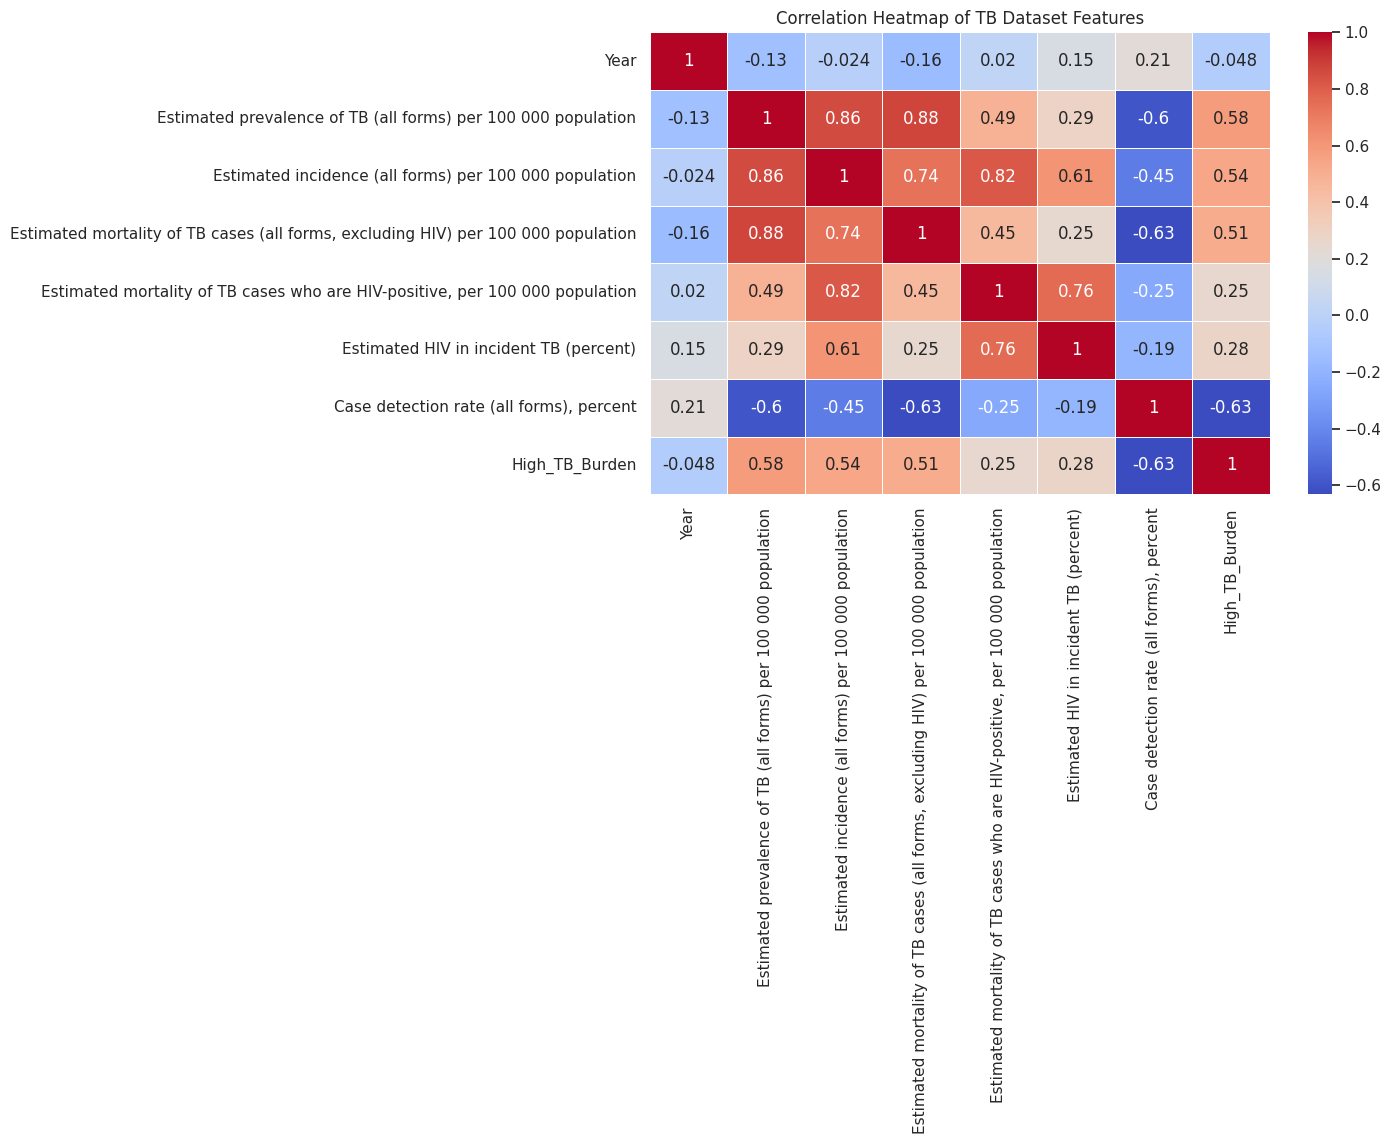

In [ ]:
# Optional: Resize the plot
plt.figure(figsize=(10, 6))

# Compute the correlation matrix
corr_matrix = df_tb_cleaned.corr(numeric_only=True)

# Plot the heatmap
sb.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of TB Dataset Features")
plt.tight_layout()
plt.show()

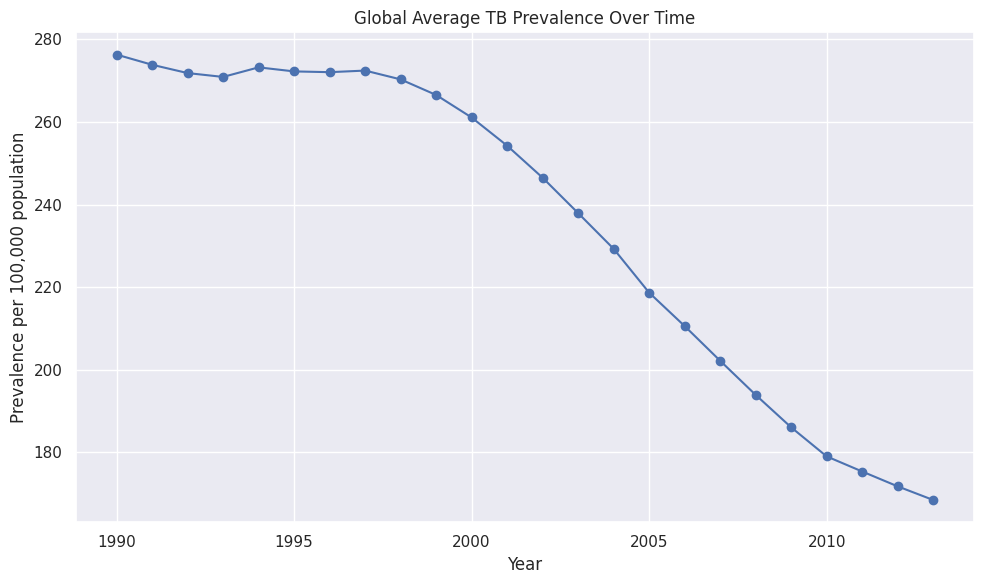

In [ ]:
# Group by year and calculate the average prevalence
global_trend = df_tb_cleaned.groupby("Year")[
    "Estimated prevalence of TB (all forms) per 100 000 population"
].mean().reset_index()

# Plot the line chart
plt.figure(figsize=(10, 6))
plt.plot(global_trend["Year"], global_trend["Estimated prevalence of TB (all forms) per 100 000 population"], marker='o')
plt.title("Global Average TB Prevalence Over Time")
plt.xlabel("Year")
plt.ylabel("Prevalence per 100,000 population")
plt.grid(True)
plt.tight_layout()
plt.show()

# **Exploratory Analysis**

For this phase, we shall explore the key factors that give rise to High TB Burden on countries

# **Box Plot**

<Figure size 1500x800 with 0 Axes>

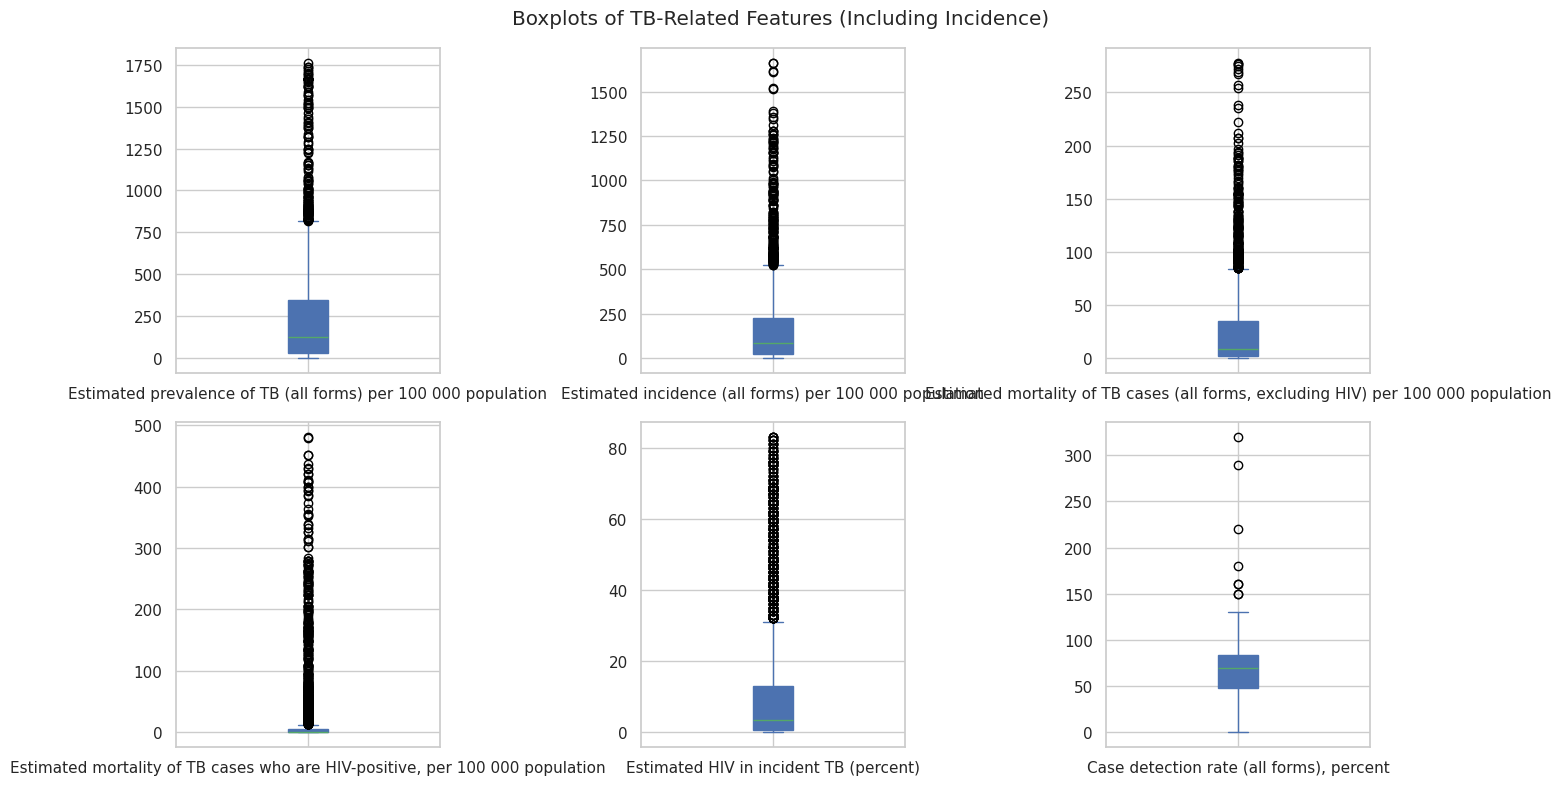

In [ ]:
sb.set(style="whitegrid")

# Select the numeric columns to plot
features = [
    "Estimated prevalence of TB (all forms) per 100 000 population",
    "Estimated incidence (all forms) per 100 000 population",
    "Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population",
    "Estimated mortality of TB cases who are HIV-positive, per 100 000 population",
    "Estimated HIV in incident TB (percent)",
    "Case detection rate (all forms), percent"
]

# Create boxplots for each selected feature
plt.figure(figsize=(15, 8))
df_tb_cleaned[features].plot(kind='box', subplots=True, layout=(2, 3), figsize=(15, 8), patch_artist=True)
plt.suptitle("Boxplots of TB-Related Features (Including Incidence)")
plt.tight_layout()
plt.show()

# **Trend over time (Global View)**

<Axes: title={'center': 'Global % of High TB Burden Countries Over Time'}, xlabel='Year'>

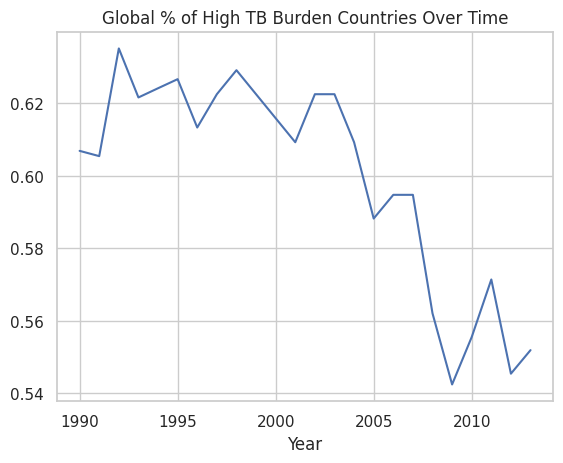

In [ ]:
df_tb_cleaned.groupby("Year")["High_TB_Burden"].mean().plot(title="Global % of High TB Burden Countries Over Time")


In [ ]:
features = [
    "Country or territory name",
    "Year",
    "Estimated prevalence of TB (all forms) per 100 000 population",
    "Estimated incidence (all forms) per 100 000 population",
    "Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population",
    "Estimated mortality of TB cases who are HIV-positive, per 100 000 population",
    "Estimated HIV in incident TB (percent)",
    "Case detection rate (all forms), percent"
]

# Drop any rows with missing values in the required columns
df_model = df_tb_cleaned.dropna(subset=features + ["High_TB_Burden"])

X = df_model[features]
y = df_model["High_TB_Burden"]

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3a: Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Step 3b: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Step 4: Evaluate both models
print("Decision Tree Results")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nRandom Forest Results")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

ValueError: could not convert string to float: 'Republic of Moldova'

In [ ]:
!python3 -m pip install pandas


In [ ]:
import pandas as pd

df = pd.read_csv("TB_Cleaned_Output FINALL.csv")


In [ ]:

df_mortality = df[
    ["Country or territory name",
     "Year",
     "Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population"]
]


In [ ]:
df_mortality.to_csv("TB_Mortality_By_Country_Year.csv", index=False)

In [ ]:
%pip install scipy

In [ ]:
import pandas as pd
from scipy.stats import zscore

df = pd.read_csv("TB_Mortality_By_Country_Year.csv")
df.columns = ["Country", "Year", "TB_Mortality_per_100k"]

df["z_score"] = df.groupby("Country")["TB_Mortality_per_100k"].transform(zscore)

df["is_anomaly"] = df["z_score"].apply(lambda z: 1 if abs(z) > 2 else 0)

df[df["is_anomaly"] == 1].head()

In [ ]:
anomaly_counts = df[df["is_anomaly"] == 1]["Country"].value_counts()
print(anomaly_counts.head(10))

In [ ]:
# Show all rows where an anomaly was detected
anomalies = df[df["is_anomaly"] == 1]

# Show a few example anomaly rows
print("🔍 Sample Anomalies Detected:")
print(anomalies.head())

# Find which countries had the most anomalies
print("\n📊 Countries with the most anomalies:")
print(anomalies["Country"].value_counts().head(10))

In [ ]:
# Show anomaly years for Morocco
print("\nMorocco anomalies:")
print(anomalies[anomalies["Country"] == "Morocco"])

# Show anomaly years for India
print("\nIndia anomalies:")
print(anomalies[anomalies["Country"] == "India"])

In [ ]:
%pip install scikit-learn

In [ ]:
import pandas as pd

# Load your filtered CSV file again
df = pd.read_csv("TB_Mortality_By_Country_Year.csv")

# Rename columns for convenience (optional but helpful)
df.columns = ["Country", "Year", "TB_Mortality_per_100k"]

In [ ]:
from sklearn.ensemble import IsolationForest

# Make a copy of the original DataFrame
df_iforest = df.copy()

# Create an empty list to store results
results = []

# Loop through each country
for country in df_iforest["Country"].unique():
    country_df = df_iforest[df_iforest["Country"] == country].copy()

    # Use 'Year' and 'TB_Mortality_per_100k' as features
    X = country_df[["Year", "TB_Mortality_per_100k"]]

    # Fit Isolation Forest model
    model = IsolationForest(contamination=0.1, random_state=42)
    country_df["is_anomaly_iforest"] = model.fit_predict(X)

    # Convert output: -1 = anomaly, 1 = normal
    country_df["is_anomaly_iforest"] = country_df["is_anomaly_iforest"].apply(lambda x: 1 if x == -1 else 0)

    # Store results
    results.append(country_df)

# Combine all countries back into one DataFrame
df_iforest = pd.concat(results)

# Show sample anomalies
df_iforest[df_iforest["is_anomaly_iforest"] == 1].head()

In [ ]:
%pip install matplotlib

In [ ]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# 2. Load the mortality-only dataset
df = pd.read_csv("TB_Mortality_By_Country_Year.csv")
df.columns = ["Country", "Year", "TB_Mortality_per_100k"]

# 3. Run Isolation Forest for each country
df_iforest = df.copy()
results = []

for country in df_iforest["Country"].unique():
    country_df = df_iforest[df_iforest["Country"] == country].copy()
    X = country_df[["Year", "TB_Mortality_per_100k"]]

    model = IsolationForest(contamination=0.1, random_state=42)
    country_df["is_anomaly_iforest"] = model.fit_predict(X)
    country_df["is_anomaly_iforest"] = country_df["is_anomaly_iforest"].apply(lambda x: 1 if x == -1 else 0)

    results.append(country_df)

df_iforest = pd.concat(results)

# 4. Plot Morocco using Isolation Forest results
morocco_ml = df_iforest[df_iforest["Country"] == "Morocco"]

plt.figure(figsize=(10, 5))
plt.plot(morocco_ml["Year"], morocco_ml["TB_Mortality_per_100k"], marker='o', label="TB Mortality")
plt.scatter(
    morocco_ml[morocco_ml["is_anomaly_iforest"] == 1]["Year"],
    morocco_ml[morocco_ml["is_anomaly_iforest"] == 1]["TB_Mortality_per_100k"],
    color="red", label="Anomaly (Isolation Forest)", zorder=5
)

plt.title("Isolation Forest - TB Mortality Anomalies in Morocco")
plt.xlabel("Year")
plt.ylabel("TB Mortality per 100,000")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Filter for India (Isolation Forest result)
india_ml = df_iforest[df_iforest["Country"] == "India"]

# Plot TB mortality with anomalies highlighted
plt.figure(figsize=(10, 5))
plt.plot(india_ml["Year"], india_ml["TB_Mortality_per_100k"], marker='o', label="TB Mortality")
plt.scatter(
    india_ml[india_ml["is_anomaly_iforest"] == 1]["Year"],
    india_ml[india_ml["is_anomaly_iforest"] == 1]["TB_Mortality_per_100k"],
    color="red", label="Anomaly (Isolation Forest)", zorder=5
)

plt.title("Isolation Forest - TB Mortality Anomalies in India")
plt.xlabel("Year")
plt.ylabel("TB Mortality per 100,000")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()